In [128]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import pandas as pd
import geopandas as gpd
from IPython.display import display


# Food Availability in Your Community Survey (June 2025 – Nov 2025)

**Data source:** Premise AEGIS for Humanitarian Needs — Ethiopia. Responses collected June 2025 through December 2025 via the *Food Availability in Your Community* survey module.

## Methodology

### Survey questions
Questions are grouped into six thematic sections: **Food Availability**, **Food Access**, **Food Shortage**, **Food Price**, **Food Affordability**, and **Open Ended**. The groupings follow the survey instrument structure and are defined in the code as named lists.

### Response percentages
All bar charts show the **percentage of respondents** who selected each response category in a given month — not raw counts. The denominator is the total number of unique respondents per month (or per month, per region for regional charts). Percentages therefore sum to 100% within each month for single-select questions.

### Regional breakdown
Each survey submission is spatially joined to Ethiopia's administrative Region boundaries using the recorded GPS coordinates (`observation_lat` / `observation_lon`). Submissions that fall outside any region boundary are excluded from regional charts. Region subplot labels show the **average number of respondents per month** in brackets, e.g. *Oromia (45)*.


In [129]:
df = pd.read_excel('../../data/premise/AEGIS for Humanitarian Needs - Ethiopia - 2025-06-01 to 2025-12-31.xlsx', sheet_name='Food Availability in Your Commu')

In [130]:
eth_adm1 = gpd.read_file('../../data/boundaries/Region_14/Regions_14.shp')

In [131]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['observation_lon'], df['observation_lat']), crs='EPSG:4326')

In [132]:
# Create mapping dictionary from submission_id to ADM1_EN
joined = gdf.sjoin(eth_adm1[['ADM1_EN', 'geometry']])[['submission_id', 'ADM1_EN']]
submission_to_region = dict(zip(joined['submission_id'], joined['ADM1_EN']))

print(f"Created mapping for {len(submission_to_region)} submissions")
print(f"Sample mappings: {dict(list(submission_to_region.items())[:5])}")

Created mapping for 3575 submissions
Sample mappings: {'"5511286973136896"': 'Oromia', '"5111893535096832"': 'Oromia', '"4838077407821824"': 'Amhara', '"6041837354221568"': 'Oromia', '"5913190953779200"': 'Oromia'}


In [133]:
open_ended = ['What is the biggest challenge your household faces in getting enough food?']

food_availability = [
    "Has food availability changed where you usually shop?",
    "Which foods are less available?"
]

food_access = [
    "How many meals does your household usually eat each day?",
       "Where did your household get most of its food?",
       "How long does it take you to get there from where you live, if walking?"

]

food_shortage =[
'In the past 7 days, did any members of your household go to bed hungry?',
       'In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?',
       'In the past 7 days, how often did your household reduce portion sizes at meals?',
       'In the past 7 days, how often did your household skip meals entirely?',
       'In the past 7 days, how often did adults reduce their food so children could eat?',
       'In the past 7 days, how often did your household limit food variety due to cost?',
]

food_price = ['Is your household buying more or less food than one month ago?',
       'Has the price of food changed in the past month where you usually shop?']

food_affordability = ["Can your current income meet your household's basic food needs?",
       "Have you sold household items or assets to buy food in the past month?",
       "Have you borrowed money or food in the past month to meet food needs?",
       "How would you rate your household's ability to access sufficient food?",
       "Do you expect your food situation to improve or worsen in the next month?"]

In [134]:
def create_stacked_percentage_chart(df, question_col, region_mapping=None, 
                                   response_order=None, color_mapping=None,
                                   width=600, height=400, facet_width=180, facet_height=150,
                                   facet_columns=4):
    # Make a copy to avoid modifying original
    df_work = df.copy()

    # Vega-Lite field accessors break on apostrophes — sanitize for field names only
    safe_col = question_col.replace("'", "").replace('"', '')
    if safe_col != question_col:
        df_work = df_work.rename(columns={question_col: safe_col})

    # Convert observed_time to datetime if needed
    if df_work['observed_time'].dtype == 'object':
        df_work['observed_time'] = pd.to_datetime(df_work['observed_time'], format='mixed', utc=True)
    
    # Extract month
    df_work['month'] = df_work['observed_time'].dt.to_period('M').astype(str)
    
    # Regional or national chart
    if region_mapping is not None:
        # Add region mapping
        df_work['region'] = df_work['submission_id'].map(region_mapping)
        df_work = df_work[df_work['region'].notna()].copy()
        
        # Group by month, region, and response
        grouped = df_work.groupby(['month', 'region', safe_col]).size().reset_index(name='count')
        
        # Calculate totals and percentages
        totals = grouped.groupby(['month', 'region'])['count'].sum().reset_index(name='total')
        grouped = grouped.merge(totals, on=['month', 'region'])
        grouped['percentage'] = (grouped['count'] / grouped['total'] * 100).round(1)
        
        # Add average respondents for region labels
        avg_respondents = totals.groupby('region')['total'].mean().round(0).astype(int).reset_index(name='avg_respondents')
        grouped = grouped.merge(avg_respondents, on='region')
        grouped['region_label'] = grouped['region'] + ' (' + grouped['avg_respondents'].astype(str) + ')'
        
        # Sorted region labels
        sorted_regions = sorted(grouped['region'].unique())
        sorted_region_labels = [r + ' (' + str(avg_respondents[avg_respondents['region'] == r]['avg_respondents'].values[0]) + ')' 
                                for r in sorted_regions]
        
        # Create faceted chart
        chart = alt.Chart(grouped).mark_bar().encode(
            x=alt.X('month:N', title='Month', axis=alt.Axis(labelAngle=-45)),
            y=alt.Y('percentage:Q', title='% of Respondents', scale=alt.Scale(domain=[0, 100])),
            color=alt.Color(f'{safe_col}:N', 
                           title='Response',
                           scale=alt.Scale(domain=response_order, range=list(color_mapping.values())) if response_order and color_mapping else alt.Undefined),
            tooltip=['region:N', 'month:N', f'{safe_col}:N', 'percentage:Q', 
                    alt.Tooltip('count:Q', title='Count'), 
                    alt.Tooltip('total:Q', title='Total Respondents')]
        ).properties(
            width=facet_width,
            height=facet_height
        ).facet(
            facet=alt.Facet('region_label:N', sort=sorted_region_labels, title=None, 
                          header=alt.Header(titleAlign='left', titleAnchor='start')),
            columns=facet_columns
        ).resolve_scale(
            y='independent'
        ).properties(
            title=alt.TitleParams(text=question_col, align='left', anchor='start', fontSize=14)
        )
        
    else:
        # National level chart
        grouped = df_work.groupby(['month', safe_col]).size().reset_index(name='count')
        
        # Calculate totals and percentages
        totals = grouped.groupby('month')['count'].sum().reset_index(name='total')
        grouped = grouped.merge(totals, on='month')
        grouped['percentage'] = (grouped['count'] / grouped['total'] * 100).round(1)
        
        # Create single chart
        chart = alt.Chart(grouped).mark_bar().encode(
            x=alt.X('month:N', title='Month', axis=alt.Axis(labelAngle=-45)),
            y=alt.Y('percentage:Q', title='Percentage of Respondents (%)', scale=alt.Scale(domain=[0, 100])),
            color=alt.Color(f'{safe_col}:N', 
                           title='Response',
                           scale=alt.Scale(domain=response_order, range=list(color_mapping.values())) if response_order and color_mapping else alt.Undefined),
            tooltip=['month:N', f'{safe_col}:N', 'percentage:Q', 
                    alt.Tooltip('count:Q', title='Count'), 
                    alt.Tooltip('total:Q', title='Total Respondents')]
        ).properties(
            width=width,
            height=height,
            title=alt.TitleParams(text=question_col, align='left', anchor='start')
        ).interactive()
    
    return chart


## Food Availability


### Which foods are less available? *(top 5, multi-select)*

*"Which foods are less available?"* allows respondents to select multiple items (delimited by `,` or `^`). Percentages for this question represent the **share of respondents who mentioned each food item** and can sum to more than 100%. Only the **top 5 most-mentioned food items** (by total frequency across all months) are shown.


- Fish, Meat, Eggs, Milk and Fruit are the top 5 responses of which foods are less available. Almost everyone said one of these was not avilable in October in Addid Ababa, which dropped very quickly in November. It may be important to note that Ethiopia's inflation also eased in October 2025.
- In Oromia, A lot more reposndants said staples were not avilable in Sep 2025


In [135]:
import altair as alt
import pandas as pd

col = 'Which foods are less available?'

# Prepare data: split multi-select responses
df_work = df[['submission_id', 'observed_time', col]].copy()
df_work['observed_time'] = pd.to_datetime(df_work['observed_time'], format='mixed', utc=True)
df_work['month'] = df_work['observed_time'].dt.to_period('M').astype(str)

# Explode multi-select: split on ',' and '^'
def explode_multiselect(frame, col):
    return (
        frame[frame[col].notna()]
        .assign(**{col: frame[col].str.split('[,^]')})
        .explode(col)
        .assign(**{col: lambda x: x[col].str.strip()})
        .loc[lambda x: x[col] != '']
    )

# Top 5 food items overall
top5 = (
    explode_multiselect(df_work, col)[col]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

# Total respondents per month (denominator)
total_per_month = df_work.groupby('month')['submission_id'].nunique().reset_index(name='total')

# National: filter to top 5
exploded = explode_multiselect(df_work, col)
exploded = exploded[exploded[col].isin(top5)]

food_monthly = (
    exploded.groupby(['month', col])['submission_id']
    .nunique()
    .reset_index(name='count')
    .merge(total_per_month, on='month')
)
food_monthly['percentage'] = (food_monthly['count'] / food_monthly['total'] * 100).round(1)

national_chart = alt.Chart(food_monthly).mark_bar().encode(
    x=alt.X('month:N', title='Month', axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('percentage:Q', title='% of Respondents'),
    color=alt.Color(f'{col}:N', title='Food Item'),
    tooltip=[
        alt.Tooltip('month:N', title='Month'),
        alt.Tooltip(f'{col}:N', title='Food Item'),
        alt.Tooltip('percentage:Q', title='% of Respondents', format='.1f'),
        alt.Tooltip('count:Q', title='Count'),
        alt.Tooltip('total:Q', title='Total Respondents'),
    ]
).properties(
    width=700,
    height=350,
    title=alt.TitleParams(text=f'{col} (Top 5)', align='left', anchor='start', fontSize=13)
).interactive()

# Regional: filter to top 5
df_work['region'] = df_work['submission_id'].map(submission_to_region)
df_work_reg = df_work[df_work['region'].notna()]
total_per_month_reg = df_work_reg.groupby(['month', 'region'])['submission_id'].nunique().reset_index(name='total')

exploded_reg = explode_multiselect(df_work_reg, col)
exploded_reg = exploded_reg[exploded_reg[col].isin(top5)]

food_monthly_reg = (
    exploded_reg.groupby(['month', 'region', col])['submission_id']
    .nunique()
    .reset_index(name='count')
    .merge(total_per_month_reg, on=['month', 'region'])
)
food_monthly_reg['percentage'] = (food_monthly_reg['count'] / food_monthly_reg['total'] * 100).round(1)

# Add avg respondents to region label
avg_resp = total_per_month_reg.groupby('region')['total'].mean().round(0).astype(int)
food_monthly_reg['region_label'] = food_monthly_reg['region'].map(
    lambda r: f"{r} ({avg_resp[r]})"
)

sorted_regions = sorted(food_monthly_reg['region'].unique())
sorted_region_labels = [f"{r} ({avg_resp[r]})" for r in sorted_regions]

regional_chart = alt.Chart(food_monthly_reg).mark_bar().encode(
    x=alt.X('month:N', title='Month', axis=alt.Axis(labelAngle=-45, labelFontSize=8)),
    y=alt.Y('percentage:Q', title='% of Respondents'),
    color=alt.Color(f'{col}:N', title='Food Item'),
    tooltip=[
        alt.Tooltip('region:N', title='Region'),
        alt.Tooltip('month:N', title='Month'),
        alt.Tooltip(f'{col}:N', title='Food Item'),
        alt.Tooltip('percentage:Q', title='% of Respondents', format='.1f'),
        alt.Tooltip('count:Q', title='Count'),
        alt.Tooltip('total:Q', title='Total Respondents'),
    ]
).properties(
    width=150,
    height=150
).facet(
    facet=alt.Facet('region_label:N', sort=sorted_region_labels, title=None,
                    header=alt.Header(labelFontSize=10, labelLimit=150)),
    columns=4
).resolve_scale(y='independent').properties(
    title=alt.TitleParams(text=f'{col} (Top 5) — by Region', align='left', anchor='start', fontSize=13)
)

display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)


### Has food availability changed where you usually shop?
There are three potential responses to this - About the same, improved and worsened. 
- Over the 6 months of 2025, more people have said 'it remained the same' in October and November. However, specifically in Addis, more people have said it worsened towards the later part of the year. A similar trends is seen in Somali., 
- There is a reduction in % of people who said the situation worsened in Afar, Amhara, Oromia (with the highest respondants). In Amahara people reported that the situation has increased. 



In [136]:
multiselect_questions = {'Which foods are less available?'}

for question in food_availability:
    if question in multiselect_questions:
        continue  # handled separately above
    national_chart = create_stacked_percentage_chart(
        df=df, question_col=question, width=700, height=300
    )
    regional_chart = create_stacked_percentage_chart(
        df=df, question_col=question,
        region_mapping=submission_to_region, facet_width=150
    )
    display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)

## Food Access

### How many meals does your household usually eat each day?
- Nearly 50% of people eat 3 meals a day in the country, with 9-13% reporting they eat just one meal. Oromia has the most repondants who said they have just 1 meal (13-26%). 

In [137]:
question = "How many meals does your household usually eat each day?"
national_chart = create_stacked_percentage_chart(df=df, question_col=question, width=700, height=300)
regional_chart = create_stacked_percentage_chart(df=df, question_col=question, region_mapping=submission_to_region, facet_width=150)
display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)

### Where did your household get most of its food?
- Nearly 40–43% of respondents reported accessing food from markets. Tigray has one of the highest market access responses (67%).
- Fewer people reported growing their own food towards the end of the year (22%) compared to the start (26.9%). This decrease is most pronounced in Addis Ababa (57% → 12.5%).


In [138]:
question = "Where did your household get most of its food?"
national_chart = create_stacked_percentage_chart(df=df, question_col=question, width=700, height=300)
regional_chart = create_stacked_percentage_chart(df=df, question_col=question, region_mapping=submission_to_region, facet_width=150)
display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)

### How long does it take you to get there from where you live, if walking?
- 30% of respondents reported accessing food from places more than 20 minutes walking distance in November 2025, up from 23% in October 2025.
- In Addis Ababa, by November 2025 most people reported travelling more than 20 minutes on foot to access food.


In [139]:
question = "How long does it take you to get there from where you live, if walking?"
national_chart = create_stacked_percentage_chart(df=df, question_col=question, width=700, height=300)
regional_chart = create_stacked_percentage_chart(df=df, question_col=question, region_mapping=submission_to_region, facet_width=150)
display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)

## Food Shortage

- In the past 7 days, did any members of your household go to bed hungry?
- In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?
- In the past 7 days, how often did your household reduce portion sizes at meals?
- In the past 7 days, how often did your household skip meals entirely?
- In the past 7 days, how often did adults reduce their food so children could eat?
- In the past 7 days, how often did your household limit food variety due to cost?



In [140]:
for question in food_shortage:
    national_chart = create_stacked_percentage_chart(
        df=df, question_col=question, width=700, height=300
    )
    regional_chart = create_stacked_percentage_chart(
        df=df, question_col=question,
        region_mapping=submission_to_region, facet_width=150
    )
    display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)

alt.VConcatChart(...)

alt.VConcatChart(...)

alt.VConcatChart(...)

alt.VConcatChart(...)

alt.VConcatChart(...)

## Food Price

- Is your household buying more or less food than one month ago?
- Has the price of food changed in the past month where you usually shop?


In [141]:
for question in food_price:
    national_chart = create_stacked_percentage_chart(
        df=df, question_col=question, width=700, height=300
    )
    regional_chart = create_stacked_percentage_chart(
        df=df, question_col=question,
        region_mapping=submission_to_region, facet_width=150
    )
    display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)

alt.VConcatChart(...)

## Food Affordability

- Can your current income meet your household's basic food needs?
- Have you sold household items or assets to buy food in the past month?
- Have you borrowed money or food in the past month to meet food needs?
- How would you rate your household's ability to access sufficient food?
- Do you expect your food situation to improve or worsen in the next month?


In [142]:
food_affordability

["Can your current income meet your household's basic food needs?",
 'Have you sold household items or assets to buy food in the past month?',
 'Have you borrowed money or food in the past month to meet food needs?',
 "How would you rate your household's ability to access sufficient food?",
 'Do you expect your food situation to improve or worsen in the next month?']

In [144]:
for question in food_affordability:
    national_chart = create_stacked_percentage_chart(
        df=df, question_col=question, width=700, height=300
    )
    regional_chart = create_stacked_percentage_chart(
        df=df, question_col=question,
        region_mapping=submission_to_region, facet_width=150
    )
    display(alt.vconcat(national_chart, regional_chart).resolve_scale(color='shared'))


alt.VConcatChart(...)

alt.VConcatChart(...)

alt.VConcatChart(...)

alt.VConcatChart(...)

alt.VConcatChart(...)

## Open Ended
Free-text responses to *"What is the biggest challenge your household faces in getting enough food?"* are translated from Amharic to English using the Google Translate API (via `deep-translator`). After translation, responses are tokenised, common stopwords and question-specific terms are removed, and word frequencies are visualised as **word clouds** — nationally and per region. The response count `n` is shown in each title.


In [121]:
import re
from collections import Counter
from wordcloud import WordCloud
from deep_translator import GoogleTranslator
from pathlib import Path

col = 'What is the biggest challenge your household faces in getting enough food?'
TRANSLATED_PATH = Path('../../data/premise/open_ended_translated.csv')

def is_amharic(text):
    return bool(re.search(r'[\u1200-\u137F\u1380-\u139F\u2D80-\u2DDF\uAB01-\uAB2E]', str(text)))

_translation_cache = {}

def translate_to_english(text):
    if pd.isna(text):
        return text
    text = str(text).strip()
    if not is_amharic(text):
        return text
    if text in _translation_cache:
        return _translation_cache[text]
    try:
        translated = GoogleTranslator(source='am', target='en').translate(text)
        _translation_cache[text] = translated
        return translated
    except Exception:
        return text

if TRANSLATED_PATH.exists():
    print(f"Loading cached translations from {TRANSLATED_PATH}")
    df_oe = pd.read_csv(TRANSLATED_PATH)
else:
    print("Translating responses (this may take a moment)...")
    df_oe = df[['submission_id', col]].copy()
    df_oe['translated'] = df_oe[col].apply(translate_to_english)
    df_oe['region'] = df_oe['submission_id'].map(submission_to_region)
    TRANSLATED_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_oe.to_csv(TRANSLATED_PATH, index=False)
    print(f"Saved to {TRANSLATED_PATH}")

print(f"Total responses: {df_oe['translated'].notna().sum()}")
df_oe.head(3)


Loading cached translations from ../../data/premise/open_ended_translated.csv
Total responses: 3574


,submission_id,What is the biggest challenge your household faces in getting enough food?,translated,region
0,"""5511286973136896""",good live 4yr,good live 4yr,Oromia
1,"""5111893535096832""",good live,good live,Oromia
2,"""4838077407821824""",less business,less business,Amhara


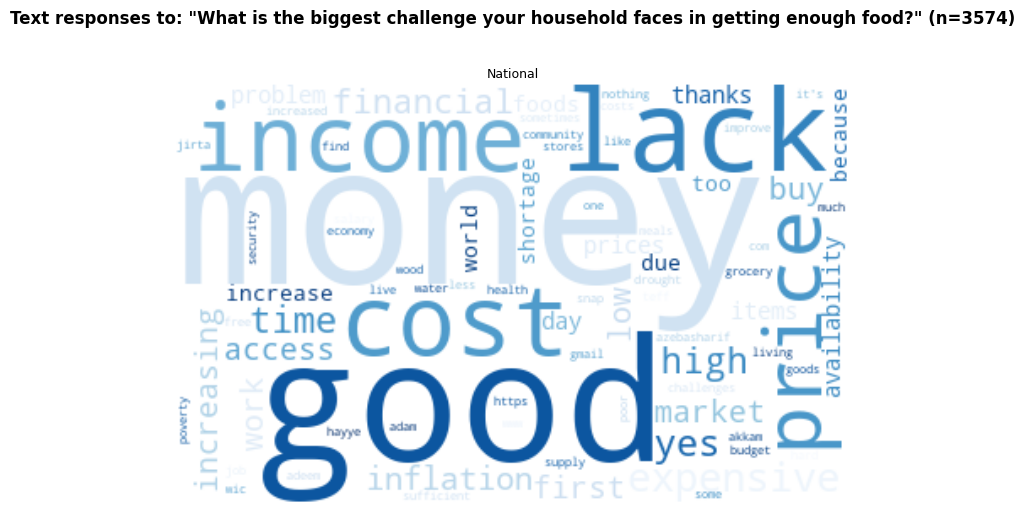

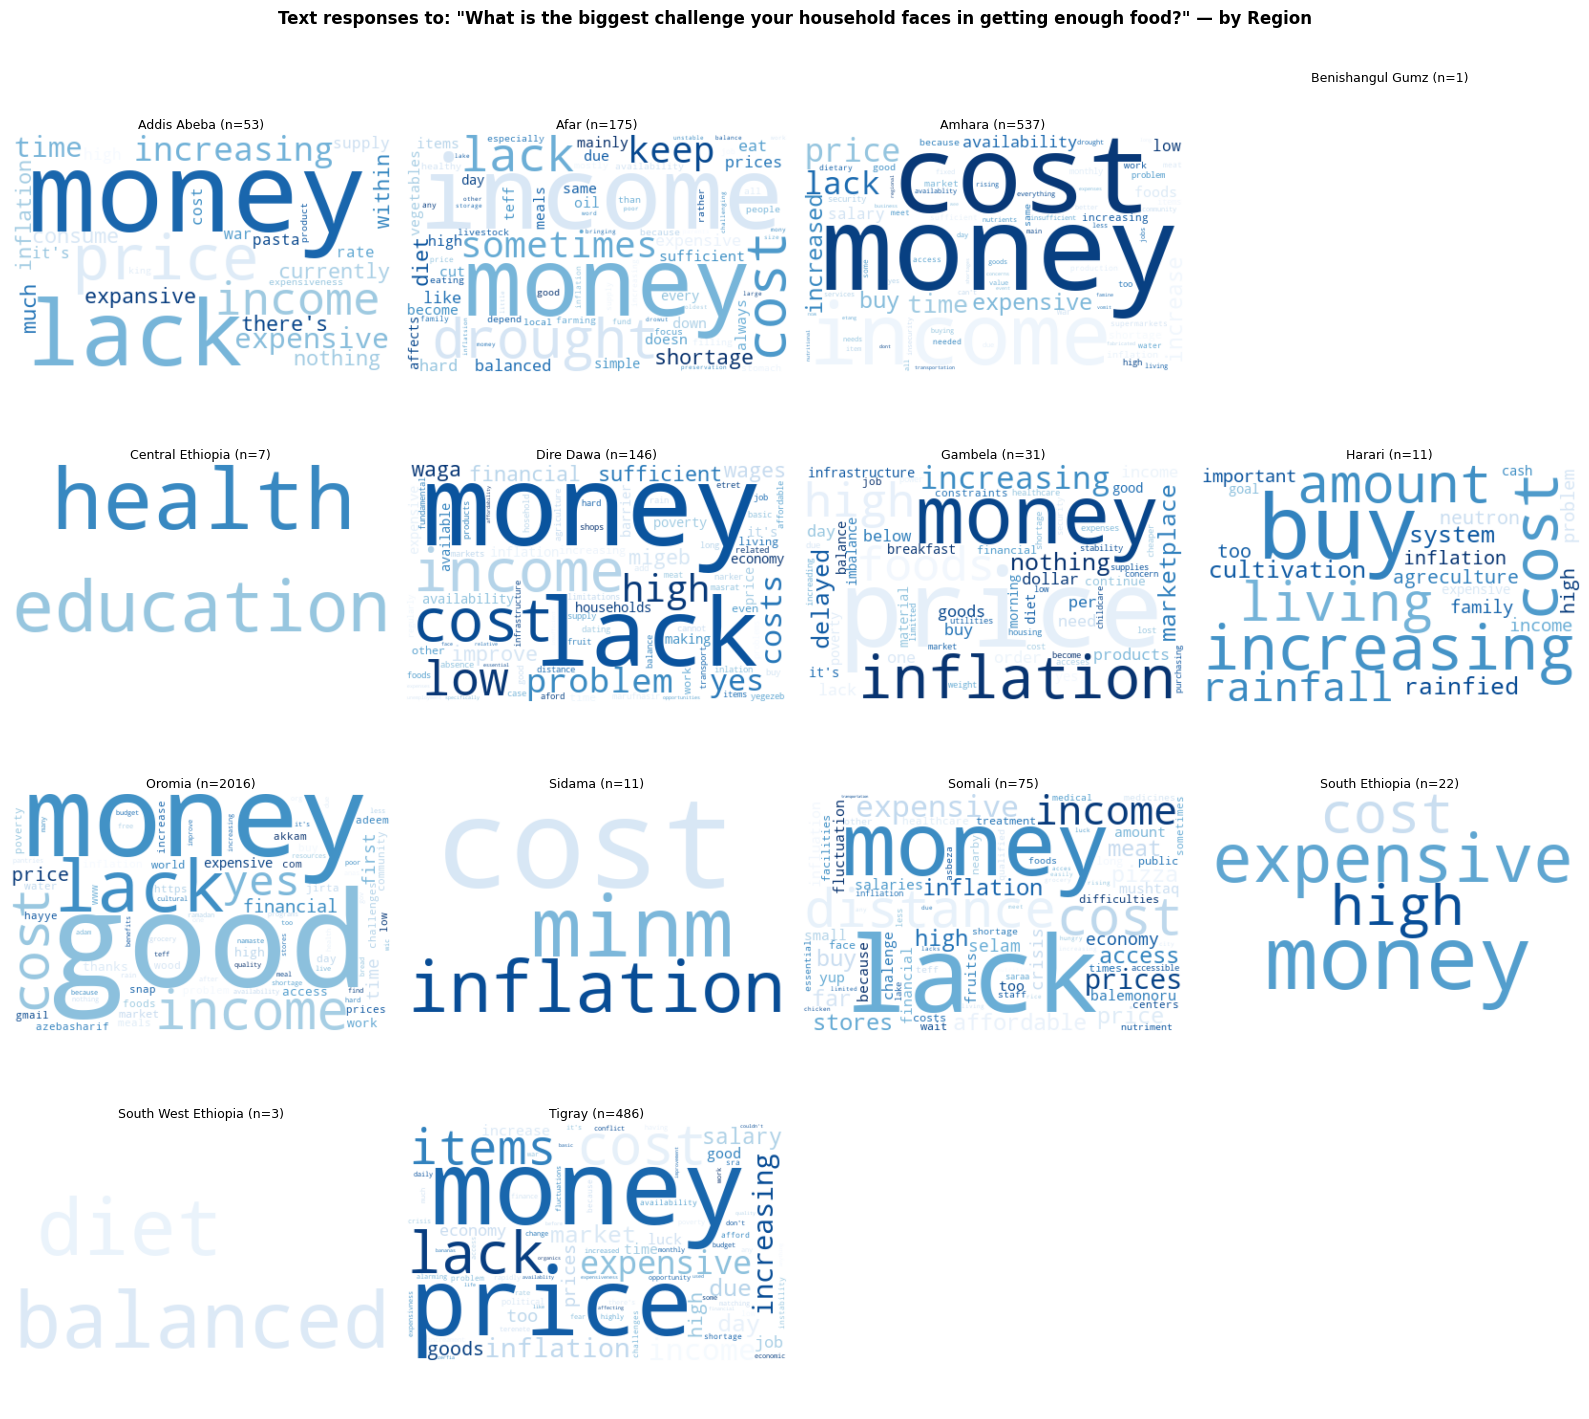

In [122]:
STOPWORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have',
    'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should',
    'may', 'might', 'shall', 'can', 'not', 'no', 'nor', 'so', 'yet', 'both',
    'either', 'neither', 'i', 'we', 'you', 'he', 'she', 'it', 'they', 'my',
    'our', 'your', 'his', 'her', 'its', 'their', 'this', 'that', 'these',
    'those', 'what', 'which', 'who', 'whom', 'how', 'when', 'where', 'why',
    'there', 'here', 'from', 'by', 'about', 'as', 'into', 'through', 'during',
    'very', 'just', 'more', 'also', 'get', 'getting', 'enough', 'food',
    'household', 'biggest', 'challenge', 'faces'
}

def tokenize(text):
    if pd.isna(text):
        return []
    words = re.findall(r"[a-z']+", str(text).lower())
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def make_wordcloud(freq_dict, title, ax):
    if not freq_dict:
        ax.axis('off')
        ax.set_title(title, fontsize=9, pad=4)
        return
    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap='Blues',
        max_words=80,
        prefer_horizontal=0.9
    ).generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=9, pad=4)

main_title = f'Text responses to: "{col}"'

# ── National ──────────────────────────────────────────────────────────────────
all_words = df_oe['translated'].apply(tokenize).explode().dropna()
national_freq = dict(Counter(all_words))
n_national = df_oe['translated'].notna().sum()

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(f'{main_title} (n={n_national})', fontsize=12, fontweight='bold', y=1.02)
make_wordcloud(national_freq, 'National', ax)
plt.tight_layout()
plt.show()

# ── Regional ──────────────────────────────────────────────────────────────────
df_oe_reg = df_oe[df_oe['region'].notna()].copy()
region_counts = df_oe_reg.groupby('region')['translated'].count()

regions = sorted(df_oe_reg['region'].unique())
n_cols = 4
n_rows = -(-len(regions) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, region in enumerate(regions):
    grp = df_oe_reg[df_oe_reg['region'] == region]
    words = grp['translated'].apply(tokenize).explode().dropna()
    freq = dict(Counter(words))
    n = region_counts.get(region, 0)
    make_wordcloud(freq, f'{region} (n={n})', axes[i])

for j in range(len(regions), len(axes)):
    axes[j].axis('off')

fig.suptitle(f'{main_title} — by Region', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Oromia Story

**More than 50% of repondants from Oromia consistently responded to be missing meals/not have food/reduce portion sizes atleast 1-3 times in the past week**. This indicates a shortage of food, or access to food. Nearly 50% of the respondants also said the availability of food where they shop 'remain the same', which could indicate that the availability was low from an earlier time. More than 50% also consistently reported having less than 3 meals a day. Nearly 20% of them grow their food at home, and 30-40% get it from a market. More than 50% of them have said the price of food has increased where they shop. However, interestingly, more than 50% of the repondants also said they're buying more food than the previous motnhs for all the months for which data is available. 

Regarding food affordability, more than 60% of them consistently said they sold household items to buy food in the past month, or borrowed money to do so. However, more than 60% have also said that they rate their access to food as 'Good' or 'Very Good'

In [146]:
# ── Oromia: percentage responses for all survey questions ────────────────────
section_map = (
    {q: 'Food Availability' for q in food_availability if q not in multiselect_questions}
    | {q: 'Food Access'       for q in food_access}
    | {q: 'Food Shortage'     for q in food_shortage}
    | {q: 'Food Price'        for q in food_price}
    | {q: 'Food Affordability' for q in food_affordability}
)

all_questions = list(section_map.keys())

# Filter df to Oromia submissions only
df_oromia = df.copy()
df_oromia['observed_time'] = pd.to_datetime(df_oromia['observed_time'], format='mixed', utc=True)
df_oromia['month'] = df_oromia['observed_time'].dt.to_period('M').astype(str)
df_oromia['region'] = df_oromia['submission_id'].map(submission_to_region)
df_oromia = df_oromia[df_oromia['region'] == 'Oromia'].copy()

rows = []
for q in all_questions:
    grouped = df_oromia.groupby(['month', q]).size().reset_index(name='count')
    totals = df_oromia.groupby('month')['submission_id'].nunique().reset_index(name='total')
    grouped = grouped.merge(totals, on='month')
    grouped['percentage'] = (grouped['count'] / grouped['total'] * 100).round(1)
    grouped.insert(0, 'question', q)
    grouped.insert(1, 'section', section_map[q])
    grouped.rename(columns={q: 'response'}, inplace=True)
    rows.append(grouped[['section', 'question', 'month', 'response', 'count', 'total', 'percentage']])

oromia_pct = pd.concat(rows, ignore_index=True)
oromia_pct


,section,question,month,response,count,total,percentage
0,Food Availability,Has food availability changed where you usuall...,2025-06,About the same,264,565,46.7
1,Food Availability,Has food availability changed where you usuall...,2025-06,Improved,237,565,41.9
2,Food Availability,Has food availability changed where you usuall...,2025-06,Worse,64,565,11.3
3,Food Availability,Has food availability changed where you usuall...,2025-07,About the same,169,375,45.1
4,Food Availability,Has food availability changed where you usuall...,2025-07,Improved,164,375,43.7
...,...,...,...,...,...,...,...
360,Food Affordability,Do you expect your food situation to improve o...,2025-10,Remain the same,134,284,47.2
361,Food Affordability,Do you expect your food situation to improve o...,2025-10,Worsen,38,284,13.4
362,Food Affordability,Do you expect your food situation to improve o...,2025-11,Improve,100,230,43.5
363,Food Affordability,Do you expect your food situation to improve o...,2025-11,Remain the same,99,230,43.0


In [153]:
# ── Food Shortage: avg % per response collapsed across all months & questions ─
shortage_summary = (
    oromia_pct[oromia_pct['section'] == 'Food Shortage']
    .groupby('response')['percentage']
    .mean()
    .round(1)
    .reset_index(name='avg_percentage')
    .sort_values('avg_percentage', ascending=False)
)
# ── Coping strategies: avg % per response collapsed across all months & questions ─
coping_questions = [
    "Have you sold household items or assets to buy food in the past month?",
    "Have you borrowed money or food in the past month to meet food needs?",
]
coping_summary = (
    oromia_pct[oromia_pct['question'].isin(coping_questions)]
    .groupby('response')['percentage']
    .mean()
    .round(1)
    .reset_index(name='avg_percentage')
    .sort_values('avg_percentage', ascending=False)
)


In [172]:

# ── Oromia Food Security Dashboard ───────────────────────────────────────────

def avg_pct_for_question(question, combine=None):
    """Average % per response for a single question, collapsed across all months.
    combine: dict mapping old response labels -> new combined label (percentages summed within month first)."""
    d = oromia_pct[oromia_pct['question'] == question].copy()
    if combine:
        d['response'] = d['response'].replace(combine)
    return (
        d.groupby(['month', 'response'])['percentage']
        .sum()
        .groupby('response')
        .mean()
        .round(1)
        .reset_index(name='avg_percentage')
        .sort_values('avg_percentage', ascending=False)
    )

def bar_chart(data, title, subtitle, width=280, height=160):
    return (
        alt.Chart(data)
        .mark_bar()
        .encode(
            x=alt.X('avg_percentage:Q', title='Avg %', scale=alt.Scale(domain=[0, 100])),
            y=alt.Y('response:N', sort='-x', title=None),
            color=alt.Color('response:N', legend=None),
            tooltip=[
                alt.Tooltip('response:N', title='Response'),
                alt.Tooltip('avg_percentage:Q', title='Avg %', format='.1f'),
            ]
        )
        .properties(
            width=width,
            height=height,
            title=alt.TitleParams(
                text=title,
                subtitle=subtitle,
                fontSize=13,
                fontWeight='bold',
                subtitleFontSize=10,
                subtitleColor='gray',
                anchor='start',
            )
        )
    )

# ── subplot 1: Food Shortage ──────────────────────────────────────────────────
sp1 = bar_chart(
    shortage_summary,
    'Food Shortage Metrics',
    'Avg % who skipped meals / ate less in the past week',
    height=130,
)

# ── subplot 2: Coping Methods ─────────────────────────────────────────────────
sp2 = bar_chart(
    coping_summary,
    'Coping Methods for Food Access',
    'Avg % who borrowed or sold items for food in the past month',
    height=80,
)

# ── subplot 3: Food Affordability (Somewhat + No combined) ────────────────────
afford_data = avg_pct_for_question(
    "Can your current income meet your household's basic food needs?",
    combine={'Somewhat': 'Somewhat / No', 'No': 'Somewhat / No'},
)
sp3 = bar_chart(
    afford_data,
    'Food Affordability',
    "Responses to 'Can your current income meet your household's basic food needs?'",
    height=100,
)

# ── subplot 4: Food Availability ──────────────────────────────────────────────
avail_data = avg_pct_for_question("Has food availability changed where you usually shop?")
sp4 = bar_chart(
    avail_data,
    'Food Availability',
    "Responses to 'Has food availability changed where you usually shop?'",
    height=100,
)

# ── subplot 5: Food Price ─────────────────────────────────────────────────────
price_data = avg_pct_for_question(
    "Has the price of food changed in the past month where you usually shop?"
)
sp5 = bar_chart(
    price_data,
    'Food Price',
    "Responses to 'Has the price of food changed in the past month where you usually shop?'",
    height=100,
)

# ── subplot 6: Food Purchasing ────────────────────────────────────────────────
buying_data = avg_pct_for_question(
    "Is your household buying more or less food than one month ago?",
    combine={
        'Slightly more': 'More (slightly or much)',
        'Much more': 'More (slightly or much)',
        'Slightly less': 'Less (slightly or much)',
        'Much less': 'Less (slightly or much)',
    },
)
sp6 = bar_chart(
    buying_data,
    'Food Purchasing',
    "Responses to 'Is your household buying more or less food than one month ago?'",
    height=100,
)

# ── Layout: 2 columns (2 + 2 + 2) ────────────────────────────────────────────
dashboard = (
    alt.vconcat(
        alt.hconcat(sp1, sp2).resolve_scale(color='independent'),
        alt.hconcat(sp3, sp4).resolve_scale(color='independent'),
        alt.hconcat(sp5, sp6).resolve_scale(color='independent'),
    )
    .properties(
        title=alt.TitleParams(
            text='Oromia Food Security — Summary Dashboard',
            subtitle='Average % of respondents per response category, collapsed across all months (Jun–Nov 2025)',
            fontSize=16,
            fontWeight='bold',
            subtitleFontSize=11,
            subtitleColor='gray',
            anchor='start',
        )
    )
    .configure_view(stroke='lightgray')
    .configure_axis(labelFontSize=11)
)

dashboard


alt.VConcatChart(...)

**Monitoring repsonses to these questions from January - March 2026**

Given Premise has provided restricted access of extracting their data for 2026, the below have been manually updated from their portal. These are responses to questions just for Oromia region from the periods Jan 1- Feb 28 and March 1 - Apr 26

**In March-Apr 2026, lesser people have reported selling their items or borrowing money for food, but more people reported that the food is pricier, and that they cannot afford it.** They also did not reported buying more food than before. 

In [161]:

# ── Oromia Jan–Apr 2026: manually extracted from Premise portal images ────────
# Source: docs/premise/Premise-*-results-Mon Apr 27 2026.png
# Region: Oromia | Period: 1 Jan 2026 – 27 Apr 2026
# Note: 'In the past 7 days, how often did your household reduce portion sizes at meals?'
#       was not available as an image and is excluded below.

_image_data = [
    # (question, response, percentage)

    # Has food availability changed where you usually shop?
    ("Has food availability changed where you usually shop?", "Improved",        36),
    ("Has food availability changed where you usually shop?", "About the same",  54),
    ("Has food availability changed where you usually shop?", "Worse",           10),

    # Has the price of food changed in the past month where you usually shop?
    ("Has the price of food changed in the past month where you usually shop?", "Increased",      48),
    ("Has the price of food changed in the past month where you usually shop?", "About the same", 44),
    ("Has the price of food changed in the past month where you usually shop?", "Decreased",       8),

    # Is your household buying more or less food than one month ago?
    ("Is your household buying more or less food than one month ago?", "Much more",              19),
    ("Is your household buying more or less food than one month ago?", "Slightly more",          32),
    ("Is your household buying more or less food than one month ago?", "The same amount of food",38),
    ("Is your household buying more or less food than one month ago?", "Slightly less",           8),
    ("Is your household buying more or less food than one month ago?", "Much less",               3),

    # In the past 7 days, did any members of your household go to bed hungry?
    ("In the past 7 days, did any members of your household go to bed hungry?", "Never (0 days)",          50),
    ("In the past 7 days, did any members of your household go to bed hungry?", "Sometimes (1-3 days)",    43),
    ("In the past 7 days, did any members of your household go to bed hungry?", "Often (4 or more days)",   7),

    # In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Never (0 days)",          48),
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Sometimes (1-3 days)",    46),
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Often (4 or more days)",   6),

    # In the past 7 days, how often did your household skip meals entirely?
    ("In the past 7 days, how often did your household skip meals entirely?", "Never (0 days)",          50),
    ("In the past 7 days, how often did your household skip meals entirely?", "Sometimes (1-3 days)",    41),
    ("In the past 7 days, how often did your household skip meals entirely?", "Often (4 or more days)",   9),

    # In the past 7 days, how often did adults reduce their food so children could eat?
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Never (0 days)",          45),
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Sometimes (1-3 days)",    46),
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Often (4 or more days)",   8),

    # In the past 7 days, how often did your household limit food variety due to cost?
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Never (0 days)",          42),
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Sometimes (1-3 days)",    49),
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Often (4 or more days)",   9),

    # Have you sold household items or assets to buy food in the past month?
    ("Have you sold household items or assets to buy food in the past month?", "Yes", 54),
    ("Have you sold household items or assets to buy food in the past month?", "No",  46),

    # Have you borrowed money or food in the past month to meet food needs?
    ("Have you borrowed money or food in the past month to meet food needs?", "Yes", 60),
    ("Have you borrowed money or food in the past month to meet food needs?", "No",  40),
]

df_apr2026 = pd.DataFrame(_image_data, columns=["question", "response", "percentage"])
df_apr2026["region"]  = "Oromia"
df_apr2026["period"]  = "Jan–Apr 2026"
df_apr2026["source"]  = "Premise portal (image)"

print(f"Rows: {len(df_apr2026)}  |  Questions: {df_apr2026['question'].nunique()}")
df_apr2026.to_csv('../../data/premise/2026_food_availability_01012026-22042026.csv', index=False)


Rows: 30  |  Questions: 10


In [174]:

# ── Oromia Mar–Apr 2026: manually extracted from Premise portal images ────────
# Source: docs/premise/01032026-30042026/Premise-*-results-Mon Apr 27 2026.png
# Region: Oromia | Period: 1 Mar 2026 – 30 Apr 2026

_image_data_mar_apr = [
    # (question, response, percentage)

    # Can your current income meet your household's basic food needs?
    ("Can your current income meet your household's basic food needs?", "Yes",      35),
    ("Can your current income meet your household's basic food needs?", "Somewhat", 52),
    ("Can your current income meet your household's basic food needs?", "No",       13),

    # Has food availability changed where you usually shop?
    ("Has food availability changed where you usually shop?", "Improved",        33),
    ("Has food availability changed where you usually shop?", "About the same",  54),
    ("Has food availability changed where you usually shop?", "Worse",           12),

    # Has the price of food changed in the past month where you usually shop?
    ("Has the price of food changed in the past month where you usually shop?", "Increased",      50),
    ("Has the price of food changed in the past month where you usually shop?", "About the same", 43),
    ("Has the price of food changed in the past month where you usually shop?", "Decreased",       7),

    # Is your household buying more or less food than one month ago?
    ("Is your household buying more or less food than one month ago?", "Much more",               17),
    ("Is your household buying more or less food than one month ago?", "Slightly more",           34),
    ("Is your household buying more or less food than one month ago?", "The same amount of food", 39),
    ("Is your household buying more or less food than one month ago?", "Slightly less",            7),
    ("Is your household buying more or less food than one month ago?", "Much less",                3),

    # In the past 7 days, did any members of your household go to bed hungry?
    ("In the past 7 days, did any members of your household go to bed hungry?", "Never (0 days)",          48),
    ("In the past 7 days, did any members of your household go to bed hungry?", "Sometimes (1-3 days)",    45),
    ("In the past 7 days, did any members of your household go to bed hungry?", "Often (4 or more days)",   6),

    # In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Never (0 days)",          49),
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Sometimes (1-3 days)",    46),
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Often (4 or more days)",   5),

    # In the past 7 days, how often did your household reduce portion sizes at meals?
    ("In the past 7 days, how often did your household reduce portion sizes at meals?", "Never (0 days)",          44),
    ("In the past 7 days, how often did your household reduce portion sizes at meals?", "Sometimes (1-3 days)",    49),
    ("In the past 7 days, how often did your household reduce portion sizes at meals?", "Often (4 or more days)",   7),

    # In the past 7 days, how often did your household skip meals entirely?
    ("In the past 7 days, how often did your household skip meals entirely?", "Never (0 days)",          50),
    ("In the past 7 days, how often did your household skip meals entirely?", "Sometimes (1-3 days)",    42),
    ("In the past 7 days, how often did your household skip meals entirely?", "Often (4 or more days)",   7),

    # In the past 7 days, how often did adults reduce their food so children could eat?
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Never (0 days)",          44),
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Sometimes (1-3 days)",    48),
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Often (4 or more days)",   8),

    # In the past 7 days, how often did your household limit food variety due to cost?
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Never (0 days)",          41),
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Sometimes (1-3 days)",    51),
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Often (4 or more days)",   9),

    # Have you sold household items or assets to buy food in the past month?
    ("Have you sold household items or assets to buy food in the past month?", "Yes", 53),
    ("Have you sold household items or assets to buy food in the past month?", "No",  47),

    # Have you borrowed money or food in the past month to meet food needs?
    ("Have you borrowed money or food in the past month to meet food needs?", "Yes", 63),
    ("Have you borrowed money or food in the past month to meet food needs?", "No",  37),

    # How would you rate your household's ability to access sufficient food?
    ("How would you rate your household's ability to access sufficient food?", "Very good",  22),
    ("How would you rate your household's ability to access sufficient food?", "Good",       44),
    ("How would you rate your household's ability to access sufficient food?", "Fair",       22),
    ("How would you rate your household's ability to access sufficient food?", "Poor",       11),
    ("How would you rate your household's ability to access sufficient food?", "Very poor",   1),
]

df_mar_apr2026 = pd.DataFrame(_image_data_mar_apr, columns=["question", "response", "percentage"])
df_mar_apr2026["region"] = "Oromia"
df_mar_apr2026["period"] = "Mar–Apr 2026"
df_mar_apr2026["source"] = "Premise portal (image)"

print(f"Rows: {len(df_mar_apr2026)}  |  Questions: {df_mar_apr2026['question'].nunique()}")
df_mar_apr2026.to_csv('../../data/premise/2026_food_availability_01032026-30042026.csv', index=False)


Rows: 41  |  Questions: 13


In [175]:

# ── Oromia Jan–Feb 2026: manually extracted from Premise portal images ────────
# Source: docs/premise/01012026-28022026/Premise-*-results-Mon Apr 27 2026.png
# Region: Oromia | Period: 1 Jan 2026 – 28 Feb 2026
# Note: includes "Can your current income..." and "reduce portion sizes" but
#       does NOT include "Have you borrowed money..." or "rate ability to access food".

_image_data_jan_feb = [
    # (question, response, percentage)

    # Can your current income meet your household's basic food needs?
    ("Can your current income meet your household's basic food needs?", "Yes",      34),
    ("Can your current income meet your household's basic food needs?", "Somewhat", 54),
    ("Can your current income meet your household's basic food needs?", "No",       12),

    # Has food availability changed where you usually shop?
    ("Has food availability changed where you usually shop?", "Improved",        39),
    ("Has food availability changed where you usually shop?", "About the same",  53),
    ("Has food availability changed where you usually shop?", "Worse",            8),

    # Has the price of food changed in the past month where you usually shop?
    ("Has the price of food changed in the past month where you usually shop?", "Increased",      47),
    ("Has the price of food changed in the past month where you usually shop?", "About the same", 44),
    ("Has the price of food changed in the past month where you usually shop?", "Decreased",       9),

    # Is your household buying more or less food than one month ago?
    ("Is your household buying more or less food than one month ago?", "Much more",               21),
    ("Is your household buying more or less food than one month ago?", "Slightly more",           30),
    ("Is your household buying more or less food than one month ago?", "The same amount of food", 39),
    ("Is your household buying more or less food than one month ago?", "Slightly less",            8),
    ("Is your household buying more or less food than one month ago?", "Much less",                3),

    # In the past 7 days, did any members of your household go to bed hungry?
    ("In the past 7 days, did any members of your household go to bed hungry?", "Never (0 days)",          52),
    ("In the past 7 days, did any members of your household go to bed hungry?", "Sometimes (1-3 days)",    41),
    ("In the past 7 days, did any members of your household go to bed hungry?", "Often (4 or more days)",   8),

    # In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Never (0 days)",          47),
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Sometimes (1-3 days)",    45),
    ("In the past 7 days, was there ever no food of any kind in your household due to lack of money or resources?", "Often (4 or more days)",   8),

    # In the past 7 days, how often did your household reduce portion sizes at meals?
    ("In the past 7 days, how often did your household reduce portion sizes at meals?", "Never (0 days)",          47),
    ("In the past 7 days, how often did your household reduce portion sizes at meals?", "Sometimes (1-3 days)",    45),
    ("In the past 7 days, how often did your household reduce portion sizes at meals?", "Often (4 or more days)",   8),

    # In the past 7 days, how often did your household skip meals entirely?
    ("In the past 7 days, how often did your household skip meals entirely?", "Never (0 days)",          50),
    ("In the past 7 days, how often did your household skip meals entirely?", "Sometimes (1-3 days)",    40),
    ("In the past 7 days, how often did your household skip meals entirely?", "Often (4 or more days)",  10),

    # In the past 7 days, how often did adults reduce their food so children could eat?
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Never (0 days)",          46),
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Sometimes (1-3 days)",    45),
    ("In the past 7 days, how often did adults reduce their food so children could eat?", "Often (4 or more days)",   9),

    # In the past 7 days, how often did your household limit food variety due to cost?
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Never (0 days)",          43),
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Sometimes (1-3 days)",    48),
    ("In the past 7 days, how often did your household limit food variety due to cost?", "Often (4 or more days)",   9),

    # Have you sold household items or assets to buy food in the past month?
    ("Have you sold household items or assets to buy food in the past month?", "Yes", 55),
    ("Have you sold household items or assets to buy food in the past month?", "No",  45),
]

df_jan_feb2026 = pd.DataFrame(_image_data_jan_feb, columns=["question", "response", "percentage"])
df_jan_feb2026["region"] = "Oromia"
df_jan_feb2026["period"] = "Jan–Feb 2026"
df_jan_feb2026["source"] = "Premise portal (image)"

print(f"Rows: {len(df_jan_feb2026)}  |  Questions: {df_jan_feb2026['question'].nunique()}")
df_jan_feb2026.to_csv('../../data/premise/2026_food_availability_01012026-28022026.csv', index=False)


Rows: 34  |  Questions: 11


### Potential Impacts of the Middle East War

In [178]:

# ── 2025 vs Jan–Feb vs Mar–Apr 2026 Combined Dashboard ───────────────────────
# Three bars per response: Jun–Nov 2025, Jan–Feb 2026, Mar–Apr 2026

# Build 2025 Oromia summary: avg % per (question, response) across all months
df_2025_summary = (
    oromia_pct
    .groupby(['question', 'response'])['percentage']
    .mean()
    .round(1)
    .reset_index()
)
df_2025_summary['period'] = 'Jun–Nov 2025'
df_2025_summary['region'] = 'Oromia'
df_2025_summary['source'] = 'Premise (2025 survey)'

df_combined_3 = pd.concat([df_2025_summary, df_jan_feb2026, df_mar_apr2026], ignore_index=True)

PERIOD_ORDER  = ['Jun–Nov 2025', 'Jan–Feb 2026', 'Mar–Apr 2026']
PERIOD_COLORS = ['#54A24B', '#4C78A8', '#F58518']

def combined_group_avg(questions):
    """Avg % per (response, period) across multiple questions."""
    return (
        df_combined_3[df_combined_3['question'].isin(questions)]
        .groupby(['response', 'period'])['percentage']
        .mean()
        .round(1)
        .reset_index(name='avg_percentage')
    )

def combined_question(question, combine=None):
    """% per (response, period) for a single question, with optional label combining."""
    d = df_combined_3[df_combined_3['question'] == question][
        ['period', 'response', 'percentage']
    ].copy()
    if combine:
        d['response'] = d['response'].replace(combine)
        d = (d.groupby(['period', 'response'])['percentage']
               .sum().round(1).reset_index())
    return d.rename(columns={'percentage': 'avg_percentage'})

def grouped_bar_chart(data, title, subtitle, width=300, height=180):
    return (
        alt.Chart(data)
        .mark_bar()
        .encode(
            x=alt.X('avg_percentage:Q', title='%', scale=alt.Scale(domain=[0, 100])),
            y=alt.Y('response:N', sort='-x', title=None),
            yOffset=alt.YOffset('period:N', sort=PERIOD_ORDER),
            color=alt.Color(
                'period:N',
                sort=PERIOD_ORDER,
                scale=alt.Scale(domain=PERIOD_ORDER, range=PERIOD_COLORS),
                title='Period',
            ),
            tooltip=[
                alt.Tooltip('period:N',         title='Period'),
                alt.Tooltip('response:N',        title='Response'),
                alt.Tooltip('avg_percentage:Q',  title='%', format='.1f'),
            ],
        )
        .properties(
            width=width,
            height=height,
            title=alt.TitleParams(
                text=title,
                subtitle=subtitle,
                fontSize=13, fontWeight='bold',
                subtitleFontSize=10, subtitleColor='gray',
                anchor='start',
            ),
        )
    )

# sp1: Food Shortage ──────────────────────────────────────────────────────────
sp1_c = grouped_bar_chart(
    combined_group_avg(food_shortage),
    'Food Shortage Metrics',
    'Avg % who skipped meals / ate less in the past week',
    height=160,
)

# sp2: Coping — sold items (common to all three periods) ──────────────────────
sp2_c = grouped_bar_chart(
    combined_question("Have you sold household items or assets to buy food in the past month?"),
    'Coping Methods for Food Access',
    'Avg % who borrowed or sold items for food in the past month',
    height=100,
)

# sp3: Food Affordability ─────────────────────────────────────────────────────
sp3_c = grouped_bar_chart(
    combined_question(
        "Can your current income meet your household's basic food needs?",
        combine={'Somewhat': 'Somewhat / No', 'No': 'Somewhat / No'},
    ),
    'Food Affordability',
    "Responses to 'Can your current income meet your household's basic food needs?'",
    height=100,
)

# sp4: Food Availability ──────────────────────────────────────────────────────
sp4_c = grouped_bar_chart(
    combined_question("Has food availability changed where you usually shop?"),
    'Food Availability',
    "Responses to 'Has food availability changed where you usually shop?'",
    height=120,
)

# sp5: Food Price ─────────────────────────────────────────────────────────────
sp5_c = grouped_bar_chart(
    combined_question("Has the price of food changed in the past month where you usually shop?"),
    'Food Price',
    "Responses to 'Has the price of food changed in the past month where you usually shop?'",
    height=120,
)

# sp6: Food Purchasing ────────────────────────────────────────────────────────
sp6_c = grouped_bar_chart(
    combined_question(
        "Is your household buying more or less food than one month ago?",
        combine={
            'Slightly more': 'More (slightly or much)',
            'Much more':     'More (slightly or much)',
            'Slightly less': 'Less (slightly or much)',
            'Much less':     'Less (slightly or much)',
        },
    ),
    'Food Purchasing',
    "Responses to 'Is your household buying more or less food than one month ago?'",
    height=120,
)

# Layout ──────────────────────────────────────────────────────────────────────
dashboard_combined = (
    alt.vconcat(
        alt.hconcat(sp1_c, sp2_c).resolve_scale(color='shared'),
        alt.hconcat(sp3_c, sp4_c).resolve_scale(color='shared'),
        alt.hconcat(sp5_c, sp6_c).resolve_scale(color='shared'),
    )
    .properties(
        title=alt.TitleParams(
            text='Oromia Food Security — 2025 vs 2026',
            subtitle='% of respondents per response category; bars grouped by period (Premise portal, Oromia only)',
            fontSize=16, fontWeight='bold',
            subtitleFontSize=11, subtitleColor='gray',
            anchor='start',
        )
    )
    .configure_view(stroke='lightgray')
    .configure_axis(labelFontSize=11)
)

dashboard_combined


alt.VConcatChart(...)